<a href="https://colab.research.google.com/github/ranimiftah12345678/PCVK26_22_Ranimiftah/blob/main/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow  # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

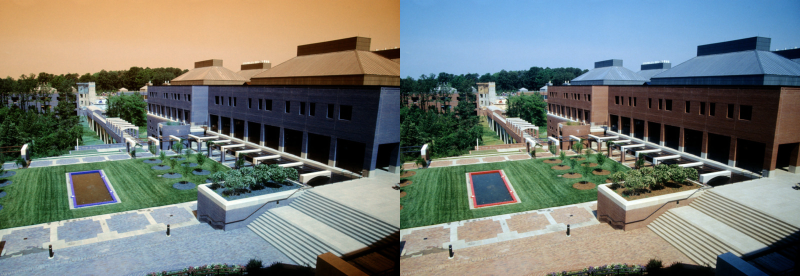

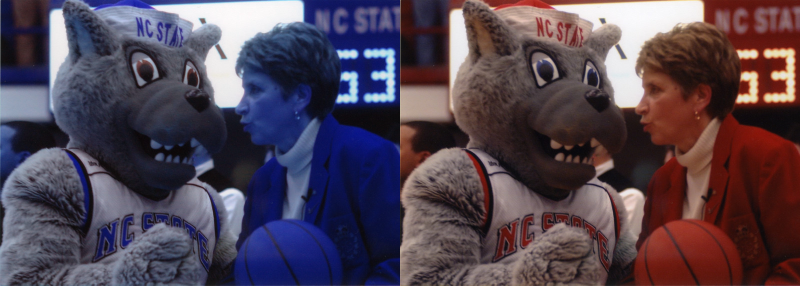

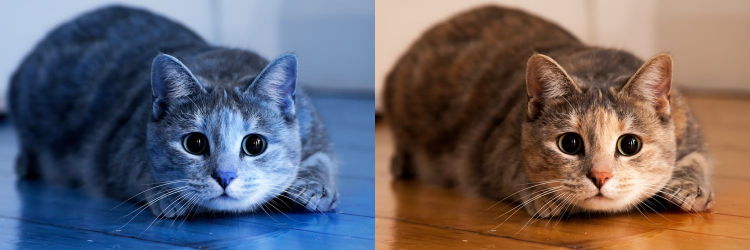

In [ ]:
# Membuat list untuk menyimpan url dari beberapa image
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://unair.ac.id/wp-content/uploads/2020/12/Kucing.jpg"]

# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in urls:
    image = io.imread(url)                               # read image
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)      # resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)       # convert color to RGB
    final_frame = cv.hconcat((image, image_2))           # concatenate image
    cv2_imshow(final_frame)                              # show image
    print('\n')

resolusi image: tinggi x lebar =  250  x  375


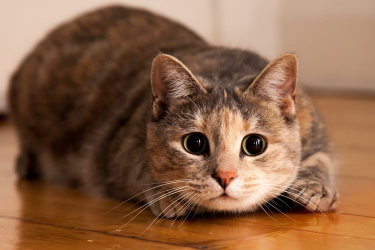

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ", tinggi, " x ", lebar)
cv2_imshow(image_2)

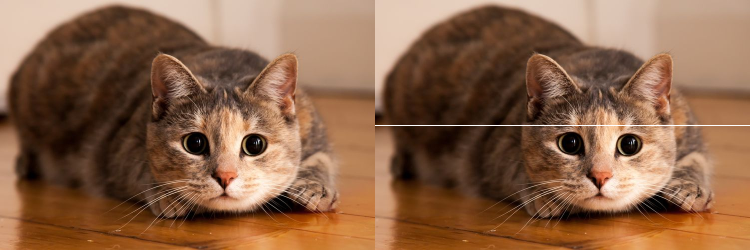

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# membuat garis horizontal ditengah image
for y in range(lebar):
    image_3[int((tinggi)/2), y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

## Pertanyaan Praktikum D2

**1. Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan menggunakan Google Colab?**

Karena Google Colab bisa langsung dipakai lewat browser tanpa perlu install Python atau library apa pun di laptop. Colab juga gratis, sudah tersedia GPU untuk mempercepat proses, dan mudah dihubungkan ke Google Drive maupun GitHub untuk menyimpan file.

---

**2. Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke delapan? Apakah semua library tersebut harus digunakan dalam praktikum sesi ini?**

- **NumPy** → untuk mengolah data dalam bentuk array/angka, termasuk data gambar.
- **Pandas** → untuk mengolah data berbentuk tabel.
- **cv2 (OpenCV)** → library utama untuk membaca dan memproses gambar.
- **cv2_imshow** → khusus dipakai di Colab untuk menampilkan gambar (karena fungsi `cv2.imshow()` biasa tidak bisa jalan di Colab).
- **skimage (io)** → untuk membaca gambar dari link/URL.
- **PIL (Pillow)** → untuk membuka dan mengedit gambar.
- **matplotlib** → untuk menampilkan gambar lengkap dengan sumbu koordinat (seperti grafik).

Tidak semua library dipakai. Yang benar-benar dipakai di praktikum ini adalah `numpy`, `cv2`, `cv2_imshow`, `skimage`, dan `matplotlib`. Pandas dan PIL cuma diimpor untuk pengenalan saja, belum benar-benar dipakai di kode.

---

**3. Pada uji coba langkah ke-9 terdapat potongan kode program berikut:**

```python
image = cv.resize(image, (0,0), fx=0.5, fy=0.5)
```

**Apa kegunaan kode program tersebut dan apa pengaruhnya jika tidak dilakukan?**

Kode ini dipakai untuk memperkecil ukuran gambar jadi setengah dari ukuran aslinya (50%). Kalau kode ini tidak dijalankan, gambar akan tetap ditampilkan dalam ukuran aslinya yang lebih besar, sehingga tampilannya jadi lebih berat dan memakan banyak ruang layar, apalagi kalau beberapa gambar digabung sekaligus.

---

**4. Perhatikan potongan kode program berikut:**

```python
# membuat garis horizontal ditengah image
for y in range(lebar):
    image_3[int((tinggi)/2), y] = [255,255,255]
```

**Apakah kegunaan kode [255,255,255]? Jelaskan!**

Angka **[255, 255, 255]** artinya warna **putih**. Ini karena dalam gambar RGB, tiap angka mewakili warna Merah, Hijau, dan Biru — kalau ketiganya diisi nilai maksimal (255), hasilnya jadi warna putih. Kode ini dipakai untuk mewarnai piksel di tengah gambar jadi putih, sehingga terbentuk garis horizontal putih di tengah gambar.

---

**5. Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun rendah!**

Pixel adalah titik-titik kecil yang menyusun sebuah gambar. Resolusi adalah jumlah pixel tersebut, dihitung dari lebar × tinggi gambar. Semakin banyak pixel (resolusi tinggi), gambar akan terlihat lebih detail dan tajam, tapi ukuran filenya juga lebih besar. Sebaliknya, kalau pixel-nya sedikit (resolusi rendah), gambar jadi terlihat kasar/pecah kalau diperbesar, tapi ukuran filenya lebih kecil dan ringan.

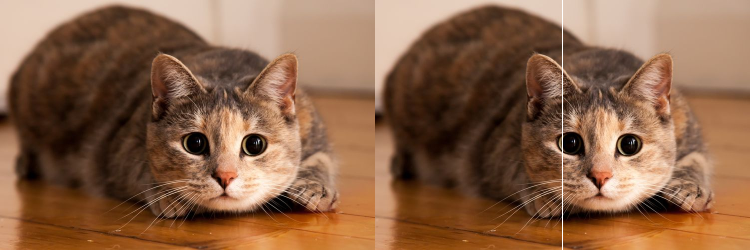

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

tinggi = image_3.shape[0]
lebar = image_3.shape[1]

# membuat garis vertikal di tengah image
for x in range(tinggi):
    image_3[x, int(lebar/2)] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

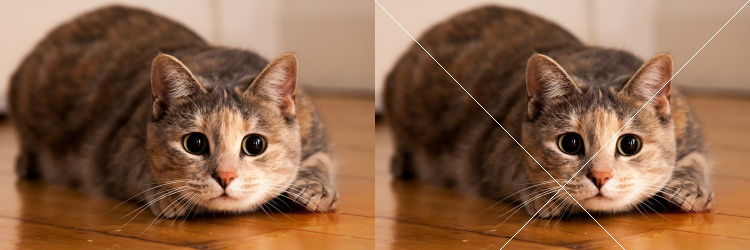

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

tinggi = image_3.shape[0]
lebar = image_3.shape[1]

# membuat garis diagonal menyilang (kiri-atas ke kanan-bawah, dan kanan-atas ke kiri-bawah)
for i in range(min(tinggi, lebar)):
    image_3[i, i] = [255, 255, 255]                       # diagonal dari kiri atas ke kanan bawah
    image_3[i, lebar - i - 1] = [255, 255, 255]            # diagonal dari kanan atas ke kiri bawah

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

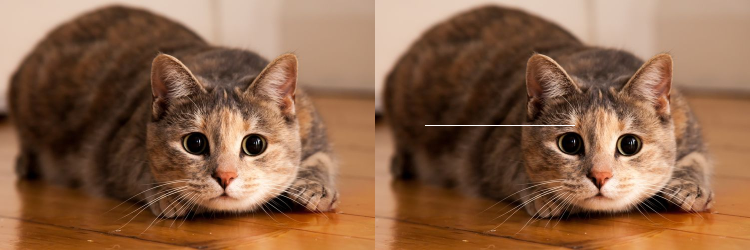

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

tinggi = image_3.shape[0]
lebar = image_3.shape[1]

# panjang garis (misal 150 piksel, dimulai dari kolom ke-50)
panjang_garis = 150
mulai_x = 50

# membuat garis horizontal di tengah gambar dengan panjang tertentu
for x in range(mulai_x, mulai_x + panjang_garis):
    image_3[int(tinggi/2), x] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

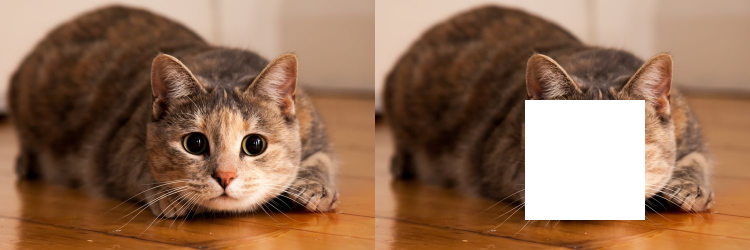

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

tinggi = image_3.shape[0]
lebar = image_3.shape[1]

# posisi & ukuran kotak (baris awal-akhir, kolom awal-akhir)
baris_awal = 100
baris_akhir = 220
kolom_awal = 150
kolom_akhir = 270

# mewarnai kumpulan pixel jadi putih membentuk kotak
for y in range(baris_awal, baris_akhir):
    for x in range(kolom_awal, kolom_akhir):
        image_3[y, x] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)